In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import numpy as np
import math
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
class Model(nn.Module):
    def __init__(self, infeatures, out_features):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(infeatures, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 512)
        self.fc5 = nn.Linear(512, 512)
        self.fc6 = nn.Linear(512, 256)
        self.fc7 = nn.Linear(256, 256)
        self.fc8 = nn.Linear(256, 256)
        self.fc9 = nn.Linear(256, 64)
        self.fc10 = nn.Linear(64, 64)
        self.fc11 = nn.Linear(64, 16)
        self.out = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = F.relu(self.fc6(x))
        x = F.relu(self.fc7(x))
        x = F.relu(self.fc8(x))
        x = F.relu(self.fc9(x))
        x = F.relu(self.fc10(x))
        x = F.relu(self.fc11(x))
        x = self.out(x)
        return x

In [74]:
 def positionalencoding(x,num_frequency=5,include_input = True):
            device = x.device
            results = []
        
            for f in range(num_frequency):
                value = (2 ** f )* math.pi * x
                # value = (2 ** f) * x
                results.append(torch.sin(value))
                results.append(torch.cos(value))
            if include_input:
                pos_out = torch.cat([x] + results, dim=-1)
            else:
                pos_out = torch.cat(results, dim=-1)
            return pos_out

In [75]:
class ImageDataloadrwithembed(Dataset):
    def __init__(self):
        path = "/home/adminnio/Downloads/Frame 5@2x (1).png"
        
        # Load and resize image
        image = Image.open(path).convert('RGB')
        image = image.resize((32, 32))  # Resize before converting to NumPy
        image_np = np.array(image).astype(np.float32)   # Normalize to [0, 1]
        # Get height and width
        self.height, self.width, _ = image_np.shape
        # Create coordinate grid
        rows, cols = np.meshgrid(np.arange(self.height), np.arange(self.width), indexing='ij')
        self.coords = np.stack((rows, cols), axis=-1).reshape(-1, 2).astype(np.float32)
        self.rgb_values = image_np.reshape(-1, 3).astype(np.float32)
        self.n_samples = self.height * self.width

    def __getitem__(self, index):
        coords = torch.tensor(self.coords[index], dtype=torch.float32)
        encoded_coord = positionalencoding(coords)
        rgb = torch.tensor(self.rgb_values[index], dtype=torch.float32)
        return encoded_coord, rgb

    def __len__(self):
        return self.n_samples


In [76]:
dataset = ImageDataloadrwithembed()
dataloader = DataLoader(dataset=dataset, batch_size=1024, shuffle=True,num_workers=0)
dataiter = iter(dataloader)
data = next(dataiter)
f,l =data

#print(l)

In [77]:
np.shape(f)

torch.Size([1024, 22])

In [72]:
f[0]

tensor([1.4000e+01, 1.8000e+01, 2.6544e-06, 1.4310e-07, 1.0000e+00, 1.0000e+00,
        5.3089e-06, 2.8620e-07, 1.0000e+00, 1.0000e+00])

In [63]:
def visualize_model_output(model, device, height, width):
    # Generate meshgrid coordinates (x, y)
    rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
    coords = np.stack((rows, cols), axis=-1).reshape(-1, 2).astype(np.float32)
    coords = torch.tensor(coords, dtype=torch.float32)
    encoded_coord = positionalencoding(coords).to(device)

    with torch.no_grad():
        output = model(encoded_coord)  

    rgb_output = output.squeeze().cpu().numpy().reshape(height, width, 3)
    
    # Normalize to [0, 1]
    min_val = rgb_output.min()
    max_val = rgb_output.max()
    if max_val > min_val:
        rgb_output = (rgb_output - min_val) / (max_val - min_val)
    else:
        rgb_output = np.zeros_like(rgb_output)  # Avoid division by zero

    print(np.shape(rgb_output))
    # Plot the RGB output
    plt.imshow(rgb_output)
    plt.axis('off')
    plt.show()


Total Training Progress:   0%|          | 0/10000 [00:00<?, ?it/s, loss=2.32e+4]

(32, 32, 3)


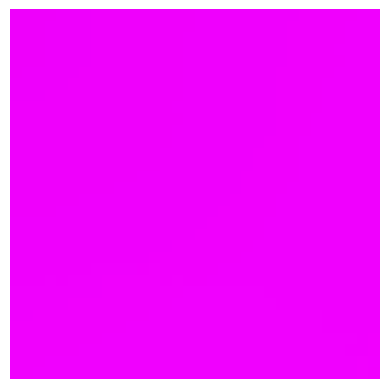

Total Training Progress:   4%| | 400/10000 [00:10<04:11, 38.10it/s, loss=3.52e+3

(32, 32, 3)


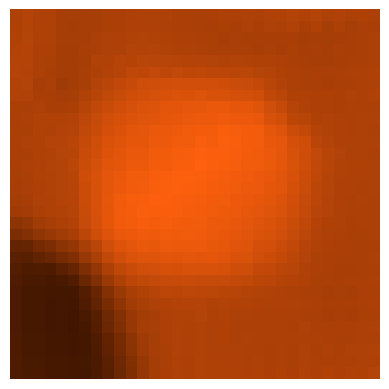

Total Training Progress:   8%| | 800/10000 [00:21<04:10, 36.69it/s, loss=3.5e+3]

(32, 32, 3)


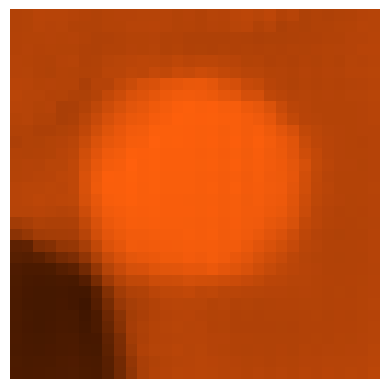

Total Training Progress:  12%| | 1200/10000 [00:32<03:48, 38.47it/s, loss=3.47e+

(32, 32, 3)


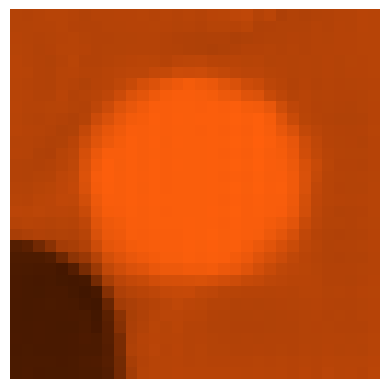

Total Training Progress:  16%|▏| 1600/10000 [00:43<03:40, 38.07it/s, loss=1.61e+

(32, 32, 3)


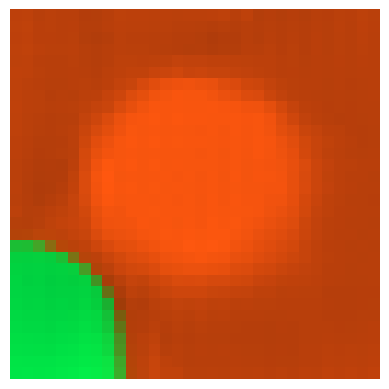

Total Training Progress:  20%|▍ | 2000/10000 [00:54<03:28, 38.42it/s, loss=11.2]

(32, 32, 3)


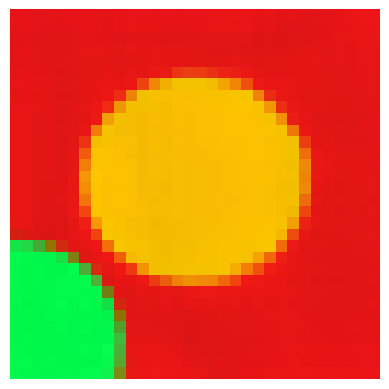

Total Training Progress:  24%|▍ | 2400/10000 [01:04<03:15, 38.82it/s, loss=5.35]

(32, 32, 3)


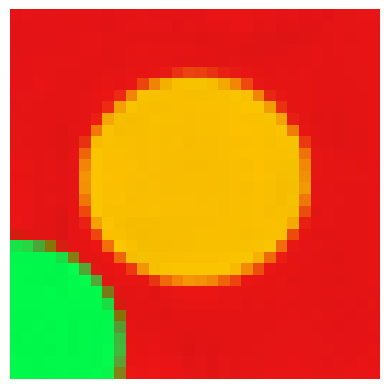

Total Training Progress:  28%|▌ | 2800/10000 [01:15<03:07, 38.44it/s, loss=3.98]

(32, 32, 3)


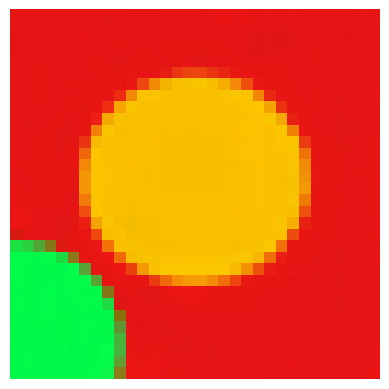

Total Training Progress:  32%|▋ | 3200/10000 [01:26<02:56, 38.56it/s, loss=5.12]

(32, 32, 3)


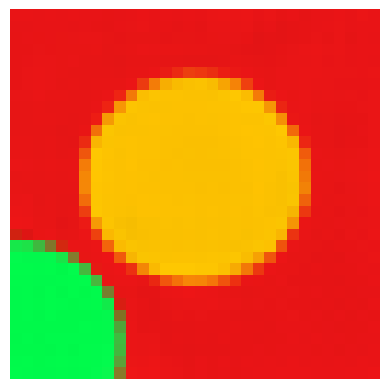

Total Training Progress:  36%|▋ | 3600/10000 [01:36<02:51, 37.35it/s, loss=3.07]

(32, 32, 3)


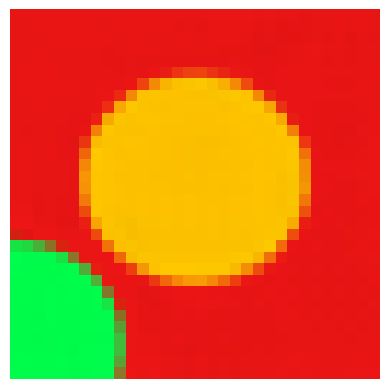

Total Training Progress:  40%|▊ | 4000/10000 [01:47<02:41, 37.07it/s, loss=9.96]

(32, 32, 3)


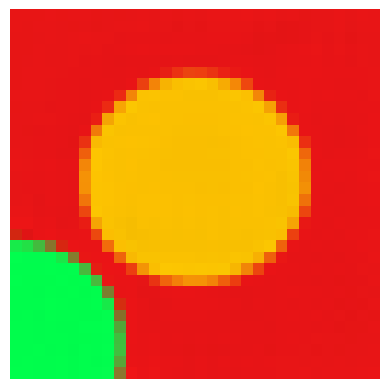

Total Training Progress:  44%|█▎ | 4401/10000 [01:58<02:25, 38.57it/s, loss=8.5]

(32, 32, 3)


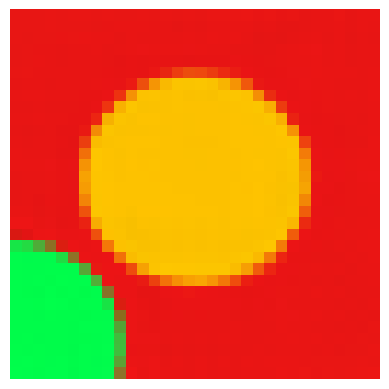

Total Training Progress:  48%|▉ | 4801/10000 [02:09<02:28, 34.95it/s, loss=1.14]

(32, 32, 3)


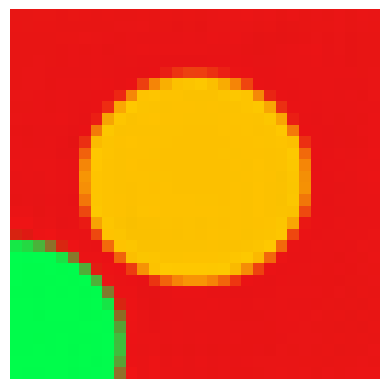

Total Training Progress:  52%|█▌ | 5201/10000 [02:19<02:29, 32.21it/s, loss=1.1]

(32, 32, 3)


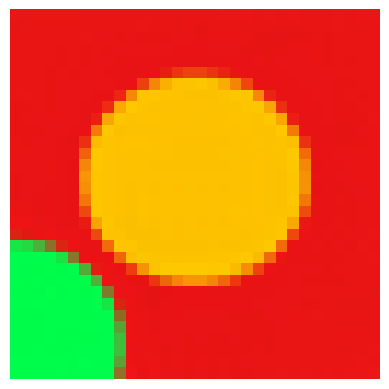

Total Training Progress:  56%|█ | 5601/10000 [02:30<01:57, 37.32it/s, loss=4.75]

(32, 32, 3)


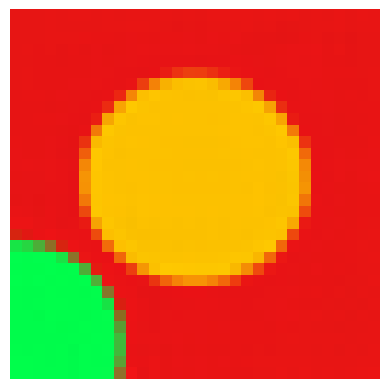

Total Training Progress:  60%|▌| 6000/10000 [02:41<01:42, 39.05it/s, loss=0.951]

(32, 32, 3)


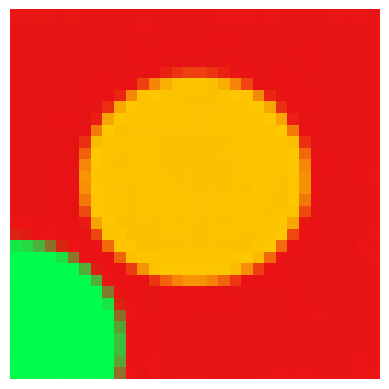

Total Training Progress:  64%|█▎| 6400/10000 [02:51<01:32, 38.81it/s, loss=1.81]

(32, 32, 3)


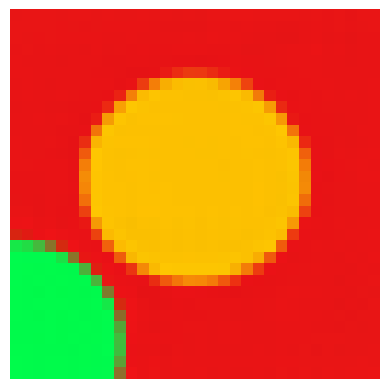

Total Training Progress:  68%|█▎| 6800/10000 [03:02<01:24, 38.01it/s, loss=0.87]

(32, 32, 3)


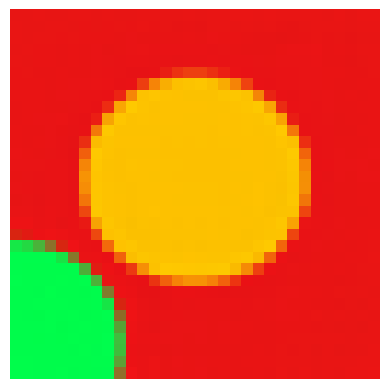

Total Training Progress:  72%|▋| 7201/10000 [03:13<01:13, 38.19it/s, loss=0.793]

(32, 32, 3)


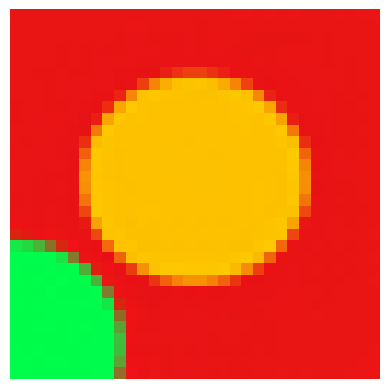

Total Training Progress:  76%|▊| 7600/10000 [03:23<01:02, 38.53it/s, loss=0.763]

(32, 32, 3)


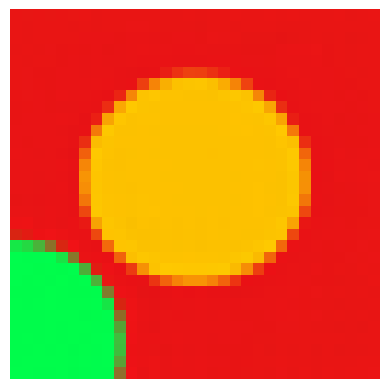

Total Training Progress:  80%|▊| 8000/10000 [03:34<00:54, 36.79it/s, loss=0.697]

(32, 32, 3)


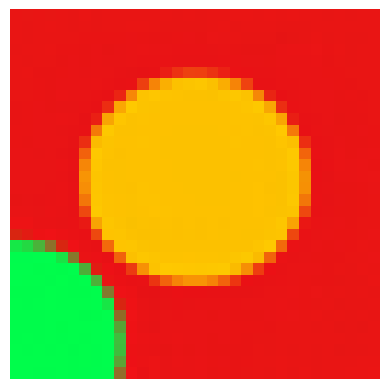

Total Training Progress:  84%|▊| 8400/10000 [03:44<00:41, 38.63it/s, loss=0.715]

(32, 32, 3)


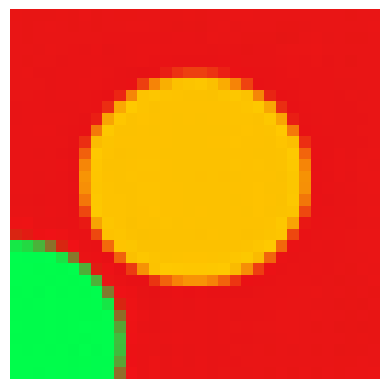

Total Training Progress:  88%|█▊| 8801/10000 [03:55<00:31, 38.45it/s, loss=17.1]

(32, 32, 3)


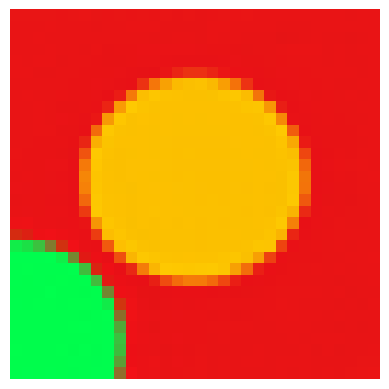

Total Training Progress:  92%|▉| 9201/10000 [04:06<00:21, 37.72it/s, loss=0.586]

(32, 32, 3)


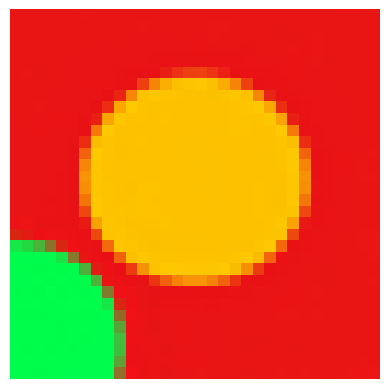

Total Training Progress:  96%|███▊| 9600/10000 [04:16<00:10, 37.08it/s, loss=48]

(32, 32, 3)


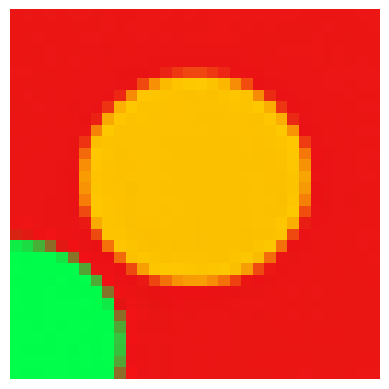

Total Training Progress: 100%|█| 10000/10000 [04:27<00:00, 37.39it/s, loss=0.505


In [80]:
from tqdm import tqdm
import torch.nn as nn

total_batches = 10
epochs = 10000 
model = Model(infeatures=22, out_features=3).to(device)
criterion = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
batches_per_epoch = len(dataloader)
total_steps = epochs * batches_per_epoch  
with tqdm(total=total_steps, desc="Total Training Progress") as pbar:
    for epoch in range(epochs):
        for features, labels in dataloader:
            features = features.to(torch.float32).to(device)
            labels = labels.to(torch.float32).to(device)

            # Forward pass
            scores = model(features)
            loss = criterion(scores, labels)
            #print(np.shape(scores))
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update the single global progress bar
            pbar.set_postfix(loss=loss.item())
            pbar.update(1)

        # Optionally visualize or log things here every N epochs
        if epoch % 400 == 0:
            with torch.no_grad():
                visualize_model_output(model, device, 32, 32)



